# Thermal PV Panel Multiclass Classifier — EfficientNet-B1 (3-class anomaly only)

**Project:** UAV-Based Photovoltaic Panel Inspection  
**Task:** Multiclass classification on anomalies only (`hotspot`, `partial_cold`, `full_cold`)  
**Model:** EfficientNet-B1 (ImageNet pretrained)  
**Input:** 240×240×3 RGB (thermal colourmap preserved)  
**Export:** TFLite float16  

**Note:** This is the **second stage** — use after the binary MobileNetV2 classifier detects an anomaly.

In [5]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow {tf.__version__} | GPUs: {[g.name for g in gpus]}')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

import os, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import EfficientNetB1
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow 2.19.0 | GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1']


In [7]:
DATA_ROOT   = Path('/kaggle/input/datasets/chellalaicha/thermal-unified/thermal_unified_processed')
TRAIN_DIR   = DATA_ROOT / 'train'
VAL_DIR     = DATA_ROOT / 'val'
TEST_DIR    = DATA_ROOT / 'test'
OUTPUT_DIR  = Path('/kaggle/working')

IMG_SIZE    = 240
BATCH_SIZE  = 32
NUM_CLASSES = 3

CLASSES = ['hotspot', 'partial_cold', 'full_cold']

LR_HEAD     = 1e-3
EPOCHS_HEAD = 8

LR_FINE1    = 1e-4
EPOCHS_FINE1= 10

LR_FINE2    = 5e-5
EPOCHS_FINE2= 12

print('Multiclass Config OK')
print(f'Classes: {CLASSES}')
print(f'Input: {IMG_SIZE}x{IMG_SIZE}x3')

Multiclass Config OK
Classes: ['hotspot', 'partial_cold', 'full_cold']
Input: 240x240x3


In [17]:
def make_dataset(directory, training=False):
    ds = keras.utils.image_dataset_from_directory(
        directory,
        labels='inferred',
        label_mode='int',
        class_names=CLASSES,
        color_mode='rgb',
        batch_size=BATCH_SIZE,
        image_size=(IMG_SIZE, IMG_SIZE),
        shuffle=training,
        seed=SEED,
    )
    # Ensure integer labels
    ds = ds.map(lambda x, y: (x, tf.cast(y, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    return ds

train_ds_raw = make_dataset(TRAIN_DIR, training=True)
val_ds_raw   = make_dataset(VAL_DIR,   training=False)
test_ds_raw  = make_dataset(TEST_DIR,  training=False)

def count_samples(directory):
    counts = {cls: len(list((Path(directory) / cls).glob('*.*'))) for cls in CLASSES}
    return counts

train_counts = count_samples(TRAIN_DIR)
print('Class distribution:')
for k, v in train_counts.items():
    print(f'  {k}: {v}')

total = sum(train_counts.values())
class_weight = {i: total / (NUM_CLASSES * v) for i, v in enumerate(train_counts.values())}
print(f'\nClass weights: {class_weight}')

Found 4326 files belonging to 3 classes.
Found 927 files belonging to 3 classes.
Found 929 files belonging to 3 classes.
Class distribution:
  hotspot: 2231
  partial_cold: 846
  full_cold: 1249

Class weights: {0: 0.6463469296279695, 1: 1.7044917257683214, 2: 1.154523618895116}


In [40]:
class FocalLoss(keras.losses.Loss):
    def __init__(self, alpha=None, gamma=2.0, name="focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        if alpha is not None:
            self.alpha = tf.constant(alpha, dtype=tf.float32)
            self.alpha_list = alpha.tolist() if hasattr(alpha, 'tolist') else list(alpha)
        else:
            self.alpha = tf.ones(NUM_CLASSES, dtype=tf.float32)
            self.alpha_list = [1.0] * NUM_CLASSES

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_onehot = tf.one_hot(y_true, depth=NUM_CLASSES)
        ce = tf.keras.losses.categorical_crossentropy(y_true_onehot, y_pred)
        pt = tf.exp(-ce)
        focal_factor = tf.pow(1.0 - pt, self.gamma)
        alpha_factor = tf.gather(self.alpha, y_true)
        return tf.reduce_mean(alpha_factor * focal_factor * ce)

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma, "alpha": self.alpha_list})
        return config

    @classmethod
    def from_config(cls, config):
        alpha = config.pop("alpha", None)
        if alpha is None:
            alpha = [1.0] * NUM_CLASSES
        return cls(alpha=alpha, **config)

In [41]:
preprocess = keras.applications.efficientnet.preprocess_input

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomBrightness(0.18),
    layers.RandomContrast(0.18),
])

@tf.function
def augment_hue(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.random_hue(image / 255.0, max_delta=0.09) * 255.0
    return tf.clip_by_value(image, 0.0, 255.0), label

def build_pipeline(ds, training=False):
    AUTOTUNE = tf.data.AUTOTUNE
    if training:
        ds = ds.map(augment_hue, num_parallel_calls=AUTOTUNE)
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = build_pipeline(train_ds_raw, training=True)
val_ds   = build_pipeline(val_ds_raw,   training=False)
test_ds  = build_pipeline(test_ds_raw,  training=False)

In [66]:
base_model = EfficientNetB1(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='swish'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),
    loss=focal_loss,
    metrics=['accuracy']
)
print("Model re-compiled with fixed FocalLoss.")

model.summary()

Model re-compiled with fixed FocalLoss.


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,234,698 (27.60 MB)

 Trainable params: 658,435 (2.51 MB)

 Non-trainable params: 6,576,263 (25.09 MB)

In [67]:
# === PHASE 1 ===
cb = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('best_efficientnetb1_multiclass.h5', save_best_only=True, monitor='val_loss')
]

print("=== Phase 1: Head only ===")
history1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=cb)

=== Phase 1: Head only ===
Epoch 1/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.5472 - loss: 0.9666

136/136 ━━━━━━━━━━━━━━━━━━━━ 102s 536ms/step - accuracy: 0.6103 - loss: 0.8004 - val_accuracy: 0.6839 - val_loss: 0.2709
Epoch 2/8
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6521 - loss: 0.5445

136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 287ms/step - accuracy: 0.6637 - loss: 0.4546 - val_accuracy: 0.7821 - val_loss: 0.2071
Epoch 3/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 289ms/step - accuracy: 0.7055 - loss: 0.3106 - val_accuracy: 0.7594 - val_loss: 0.2219
Epoch 4/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.7198 - loss: 0.2571 - val_accuracy: 0.7314 - val_loss: 0.2264
Epoch 5/8
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.7167 - loss: 0.2392

136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.7282 - loss: 0.2362 - val_accuracy: 0.7357 - val_loss: 0.1925
Epoch 6/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 279ms/step - accuracy: 0.7235 - loss: 0.2324 - val_accuracy: 0.7627 - val_loss: 0.2152
Epoch 7/8
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7311 - loss: 0.2217

136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 280ms/step - accuracy: 0.7390 - loss: 0.2182 - val_accuracy: 0.7551 - val_loss: 0.1880
Epoch 8/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.7473 - loss: 0.2139 - val_accuracy: 0.7767 - val_loss: 0.1926


In [70]:
# === PHASE 2 ===
print("=== Phase 2: Top layers ===")
for layer in base_model.layers[-int(len(base_model.layers)*0.33):]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(LR_FINE1), loss=focal_loss, metrics=['accuracy'])
history2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE1, callbacks=cb)

=== Phase 2: Top layers ===
Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8949 - loss: 0.0653

136/136 ━━━━━━━━━━━━━━━━━━━━ 117s 545ms/step - accuracy: 0.9029 - loss: 0.0600 - val_accuracy: 0.9040 - val_loss: 0.0498
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 273ms/step - accuracy: 0.9096 - loss: 0.0546 - val_accuracy: 0.9061 - val_loss: 0.0565
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.9087 - loss: 0.0553 - val_accuracy: 0.9040 - val_loss: 0.0572
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 273ms/step - accuracy: 0.9122 - loss: 0.0508 - val_accuracy: 0.9148 - val_loss: 0.0547
Epoch 5/10
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9124 - loss: 0.0459

136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 279ms/step - accuracy: 0.9135 - loss: 0.0515 - val_accuracy: 0.9137 - val_loss: 0.0494
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 275ms/step - accuracy: 0.9015 - loss: 0.0612 - val_accuracy: 0.9094 - val_loss: 0.0575
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 275ms/step - accuracy: 0.9149 - loss: 0.0475 - val_accuracy: 0.9126 - val_loss: 0.0536
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.9177 - loss: 0.0443 - val_accuracy: 0.9072 - val_loss: 0.0522
Epoch 9/10
135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9196 - loss: 0.0426

136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 279ms/step - accuracy: 0.9242 - loss: 0.0411 - val_accuracy: 0.9169 - val_loss: 0.0476
Epoch 10/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.9242 - loss: 0.0423 - val_accuracy: 0.9105 - val_loss: 0.0558


In [72]:
# === PHASE 3 ===
print("=== Phase 3: Full base ===")
for layer in base_model.layers:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(LR_FINE2), loss=focal_loss, metrics=['accuracy'])
history3 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE2, callbacks=cb)

=== Phase 3: Full base ===
Epoch 1/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9108 - loss: 0.0446

136/136 ━━━━━━━━━━━━━━━━━━━━ 152s 636ms/step - accuracy: 0.9205 - loss: 0.0404 - val_accuracy: 0.9223 - val_loss: 0.0431
Epoch 2/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 284ms/step - accuracy: 0.9265 - loss: 0.0398 - val_accuracy: 0.9148 - val_loss: 0.0440
Epoch 3/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.9242 - loss: 0.0415 - val_accuracy: 0.9245 - val_loss: 0.0433
Epoch 4/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9262 - loss: 0.0364

136/136 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.9311 - loss: 0.0350 - val_accuracy: 0.9245 - val_loss: 0.0416
Epoch 5/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9226 - loss: 0.0351

136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 289ms/step - accuracy: 0.9302 - loss: 0.0357 - val_accuracy: 0.9213 - val_loss: 0.0412
Epoch 6/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 282ms/step - accuracy: 0.9304 - loss: 0.0365 - val_accuracy: 0.9159 - val_loss: 0.0537
Epoch 7/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 283ms/step - accuracy: 0.9295 - loss: 0.0381 - val_accuracy: 0.9148 - val_loss: 0.0564
Epoch 8/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 281ms/step - accuracy: 0.9316 - loss: 0.0383 - val_accuracy: 0.9159 - val_loss: 0.0477
Epoch 9/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 282ms/step - accuracy: 0.9346 - loss: 0.0318 - val_accuracy: 0.9256 - val_loss: 0.0435
Epoch 10/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9268 - loss: 0.0340

136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.9350 - loss: 0.0310 - val_accuracy: 0.9256 - val_loss: 0.0390
Epoch 11/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 284ms/step - accuracy: 0.9320 - loss: 0.0356 - val_accuracy: 0.9148 - val_loss: 0.0510
Epoch 12/12
136/136 ━━━━━━━━━━━━━━━━━━━━ 39s 283ms/step - accuracy: 0.9355 - loss: 0.0337 - val_accuracy: 0.9180 - val_loss: 0.0491


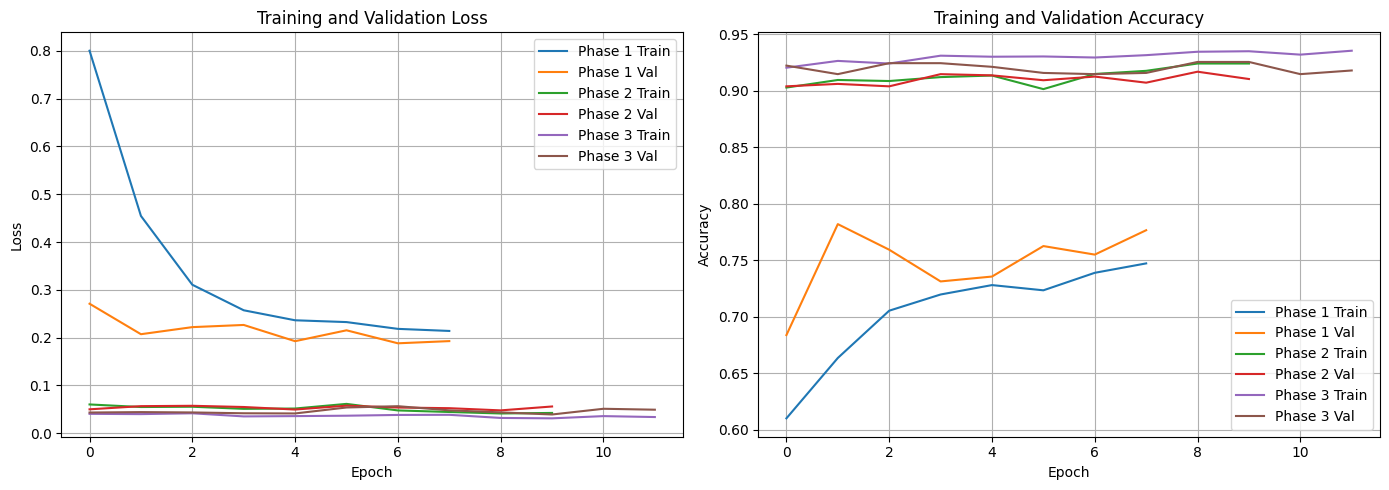

In [73]:
# === TRAINING CURVES ===
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Phase 1 Train')
plt.plot(history1.history['val_loss'], label='Phase 1 Val')
plt.plot(history2.history['loss'], label='Phase 2 Train')
plt.plot(history2.history['val_loss'], label='Phase 2 Val')
plt.plot(history3.history['loss'], label='Phase 3 Train')
plt.plot(history3.history['val_loss'], label='Phase 3 Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], label='Phase 1 Train')
plt.plot(history1.history['val_accuracy'], label='Phase 1 Val')
plt.plot(history2.history['accuracy'], label='Phase 2 Train')
plt.plot(history2.history['val_accuracy'], label='Phase 2 Val')
plt.plot(history3.history['accuracy'], label='Phase 3 Train')
plt.plot(history3.history['val_accuracy'], label='Phase 3 Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

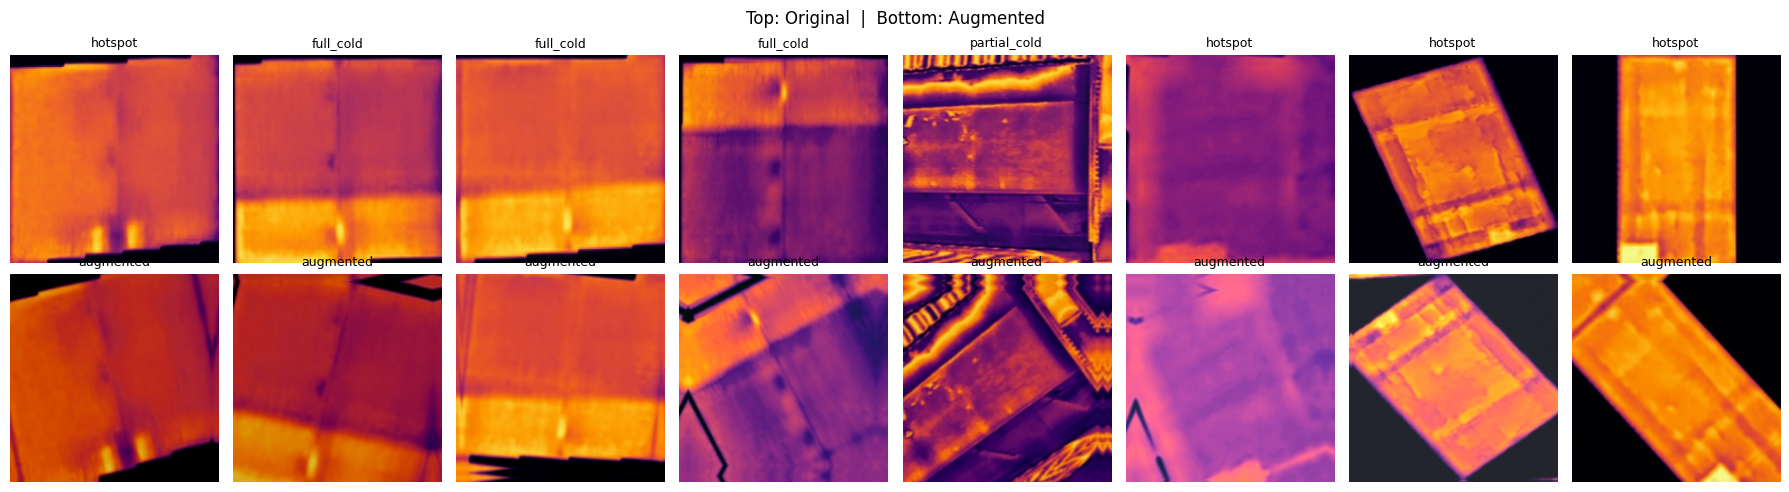

In [74]:
# === AUGMENTATION PREVIEW ===
sample_images, sample_labels = next(iter(train_ds_raw.take(1)))
aug_images, _ = augment_hue(sample_images[:8], sample_labels[:8])
aug_images = augmentation(aug_images, training=True)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    axes[0, i].imshow(sample_images[i].numpy().astype('uint8'))
    axes[0, i].set_title(CLASSES[sample_labels[i]], fontsize=9)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(tf.clip_by_value(aug_images[i], 0, 255).numpy().astype('uint8'))
    axes[1, i].set_title('augmented', fontsize=9)
    axes[1, i].axis('off')

fig.suptitle('Top: Original  |  Bottom: Augmented', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_preview.png', dpi=150)
plt.show()

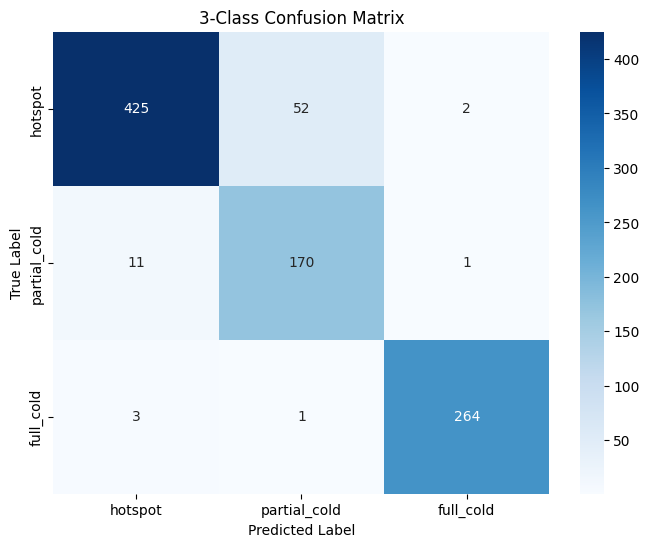

In [75]:
# === CONFUSION MATRIX ===
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('3-Class Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

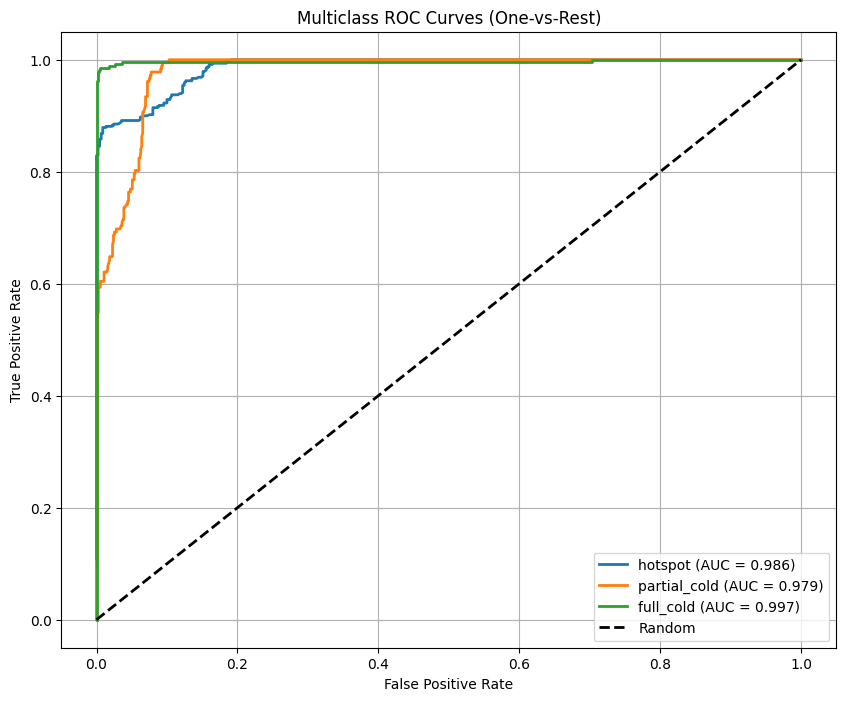

In [76]:
# === ROC CURVES ===
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

true_bin = label_binarize(true_labels, classes=range(NUM_CLASSES))

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(true_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{CLASSES[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

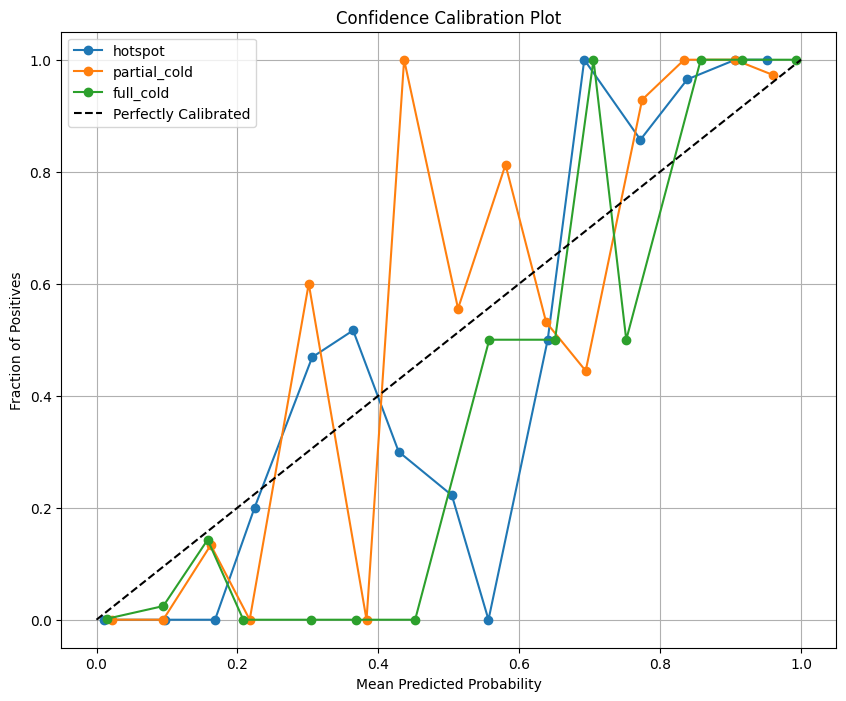


=== Average Confidence Analysis ===
hotspot      | Avg: 0.8425 | Correct: 0.9060 | Wrong: 0.3427
partial_cold | Avg: 0.7625 | Correct: 0.7940 | Wrong: 0.3162
full_cold    | Avg: 0.9685 | Correct: 0.9814 | Wrong: 0.1135


In [77]:
# === CONFIDENCE CALIBRATION ===
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(CLASSES):
    prob_true, prob_pred = calibration_curve(
        (true_labels == i).astype(int), 
        test_probs[:, i], 
        n_bins=15
    )
    plt.plot(prob_pred, prob_true, marker='o', label=class_name)

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Confidence Calibration Plot')
plt.legend()
plt.grid(True)
plt.show()

# === AVERAGE CONFIDENCE (like in binary notebook) ===
print("\n=== Average Confidence Analysis ===")
correct = test_preds == true_labels
for i, cls in enumerate(CLASSES):
    mask = true_labels == i
    if mask.sum() > 0:
        avg_conf = test_probs[mask, i].mean()
        conf_when_correct = test_probs[mask & correct, i].mean() if (mask & correct).sum() > 0 else 0
        conf_when_wrong   = test_probs[mask & ~correct, i].mean() if (mask & ~correct).sum() > 0 else 0
        print(f"{cls:12} | Avg: {avg_conf:.4f} | Correct: {conf_when_correct:.4f} | Wrong: {conf_when_wrong:.4f}")

In [55]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

with open(OUTPUT_DIR / 'thermal_multiclass_efficientnetb1_f16.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ TFLite float16 model exported successfully!")

INFO:tensorflow:Assets written to: /tmp/tmpyq749_j_/assets


INFO:tensorflow:Assets written to: /tmp/tmpyq749_j_/assets


Saved artifact at '/tmp/tmpyq749_j_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 240, 240, 3), dtype=tf.float32, name='input_layer_25')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133710810096336: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133710810100560: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133710810100752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810100176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810096720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810101520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810102096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810099792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810099408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133710810101904: TensorSpec(shape=(), dtype=tf.resource, name=No

W0000 00:00:1781008105.562663      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781008105.562717      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1781008105.864988      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


✅ TFLite float16 model exported successfully!
